# Testing sessions:

In [ ]:
x = 1


In [ ]:
print(x*2)


# Timer formatting

Rounds by default, and shows by default:

In [ ]:
print(1)
import time
time.sleep(3)


Turn off timer-show to hide it

In [ ]:
print(1)


Set :timer-rounded to no to get the full timer. (Also modifying the
timer string here so that my expect tests will skip it.)

In [ ]:
print(1)


# Table formatting

## As org tables

By default dataframes are printed as org tables

In [ ]:
import pandas as pd
data = {
'Name': ['Joe', 'Eva', 'Charlie', 'David', 'Eva'],
'Age': [44, 32, 33,33, 22],
'City': ['New York', 'San Francisco', 'Boston', 'Paris', 'Tokyo'],
'Score': [92.5, 88.0, 95.2, 78.9, 90.11111]}
df = pd.DataFrame(data)
print(df)


| idx | Name    | Age | City          | Score    |
|-----|---------|-----|---------------|----------|
| 0   | Joe     | 44  | New York      | 92.5     |
| 1   | Eva     | 32  | San Francisco | 88.0     |
| 2   | Charlie | 33  | Boston        | 95.2     |
| 3   | David   | 33  | Paris         | 78.9     |
| 4   | Eva     | 22  | Tokyo         | 90.11111 |

This respects various pandas options:

Float formatting

In [ ]:
pd.options.display.float_format = '{:.1f}'.format
print(df.set_index("Name"))


Max rows

In [ ]:
pd.options.display.max_rows = 10
long_df = pd.DataFrame({'A': range(200)})
print(long_df)


### Problem – hangs when printing large dataframes.

print<sub>orgdf</sub> sets max<sub>rows</sub> to be 20 by default to
avoid this issue.

In [ ]:
import pandas as pd
long_df = pd.DataFrame({'A': range(400)})
print(long_df)


If we make the max<sub>rows</sub> even modestly large, we run into it,
depending on computing resources.

In [ ]:
pd.options.display.max_rows = 200
long_df = pd.DataFrame({'A': range(200)})
print(long_df)


### Printing multiple dataframes:

In [ ]:
print(df)
print("Space between dataframes")
print(df)


In general space between dataframes requires ones below to be aligned. I
have an advise function ( adjust-org-babel-results ) that does this, but
it can be slow if there are many tables in the org file, so it can be
disabled like this.

In [ ]:
print(df)
print("Space between dataframes")
print(df)


### Bug – tables that contain \| are buggy.

Need a way to handle \|'s in the string names

In [ ]:
import pandas as pd


df = pd.DataFrame({"names": ["John \vert", "Mary", "Bob  Rob", "Alice John", "Tom"]})
print(df)


|     | names |
|-----|-------|
| 0   | John  |

ert \\

|     |            |
|-----|------------|
| 1   | Mary       |
| 2   | Bob Rob    |
| 3   | Alice John |
| 4   | Tom        |

One work around is to call to<sub>markdown</sub> directly, as
ob-python-extras converts \| that are not in dataframes into \\ to
prevent org from incorrectly recognizing text as tables.

In [ ]:
import pandas as pd

df = pd.DataFrame({"names": ["John", "Mary", "Bob|Rob", "Alice|John", "Tom"]})
print(df.to_markdown())


\\ \\ names \\ \\:\\———–\\ \\ 0 \\ John \\ \\ 1 \\ Mary \\ \\ 2 \\ Bob
\\ \\ 3 \\ Alice \\ \\ 4 \\ Tom \\

## Displaying styled dataframes as pngs

Dataframes can also be displayed as styled dataframes. This is nice for
exporting documents with pretty tables.

In [ ]:
styled_df = df.style.background_gradient()
print(styled_df)


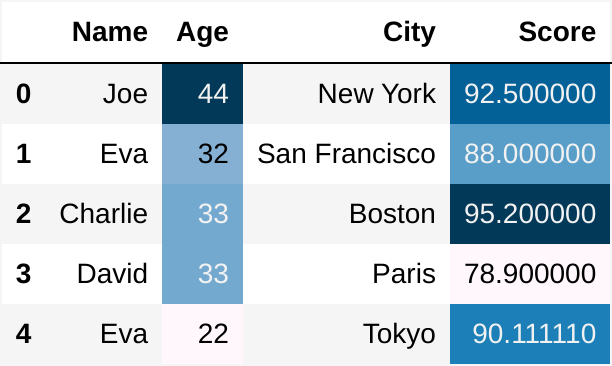

## Polars

Polars dataframes are always printed as an org table as well.

In [ ]:
import polars as pl

df = pl.DataFrame({"x": [1, 1, 3], "y": [2, 3, 1]})
df


(3, 2)

| idx | x   | y   |
|-----|-----|-----|
| 0   | 1   | 2   |
| 1   | 1   | 3   |
| 2   | 3   | 1   |

Cell Timer: 0:00:00

# Testing Tabulate

If Tabulate is available we can use it directly to formate the
dataframe. This is built into pandas and the safer option.

In [ ]:
import pandas as pd
data = {
'Name': ['Joe', 'Eva', 'Charlie', 'David', 'Eva'],
'Age': [44, 32, 33,33, 22],
'City': ['New York', 'San Francisco', 'Boston', 'Paris', 'Tokyo'],
'Score': [92.5, 88.0, 95.2, 78.9, 90.11111]}
df = pd.DataFrame(data)
print(df)


# Images

mocks out python plotting to allow plots to be interspersed with
printing, and allows multiple to be made. :)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

print("look!")
df = pd.DataFrame(
    {
        "x": [0, 2, 3, 4, 5, 6, 7],
        "y": [10, 11, 12, 13, 14, 15, 16],
    }
)
print(df)
df.plot(x="x", y="y", kind="line")
plt.show()
print("tada!")


# Alerts on finishing

When this finishes, it alerts you in an emacs minibuffer, with a link
back. You also get a system alert. (This requires libnotify to be
installed.)

In [ ]:
import time
print("waiting")
time.sleep(1)
print("finished")


In [ ]:
import time
print("waiting")
time.sleep(1)
print("finished")


I also have it configured to send an alert for any cell that takes more
than 10 seconds.

# HTML formatting

In [ ]:
import base64
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create sample data
df = pd.DataFrame(
    {
        "x": np.linspace(0, 10, 100),
        "sin": np.sin(np.linspace(0, 10, 100)),
        "cos": np.cos(np.linspace(0, 10, 100)),
    }
)

# Create matplotlib plot
plt.figure(figsize=(8, 4))
plt.plot(df["x"][:20], df["sin"][:20], label="sin")
plt.plot(df["x"][:20], df["cos"][:20], label="cos")
plt.legend()
plt.title("Sine and Cosine Waves")

# Convert plot to base64
buf = BytesIO()
plt.savefig(buf, format="png")
plt.close()
img_base64 = base64.b64encode(buf.getvalue()).decode("utf-8")

# Create HTML with table and image
html = f"""
<h1>Data Analysis Results</h1>
<p>Here's a sample of our trigonometric functions:</p>
{df.head().to_html(classes='dataframe')}
<p><b>Visualization:</b></p>
<img src="data:image/png;base64,{img_base64}"/>
<p><i>Figure 1: First few periods of sine and cosine waves</i></p>
"""

print(html)


-   Data Analysis Results

Here's a sample of our trigonometric functions:

|     | x       | sin      | cos      |
|-----|---------|----------|----------|
| 0   | 0.00000 | 0.000000 | 1.000000 |
| 1   | 0.10101 | 0.100838 | 0.994903 |
| 2   | 0.20202 | 0.200649 | 0.979663 |
| 3   | 0.30303 | 0.298414 | 0.954437 |
| 4   | 0.40404 | 0.393137 | 0.919480 |

**Visualization:**

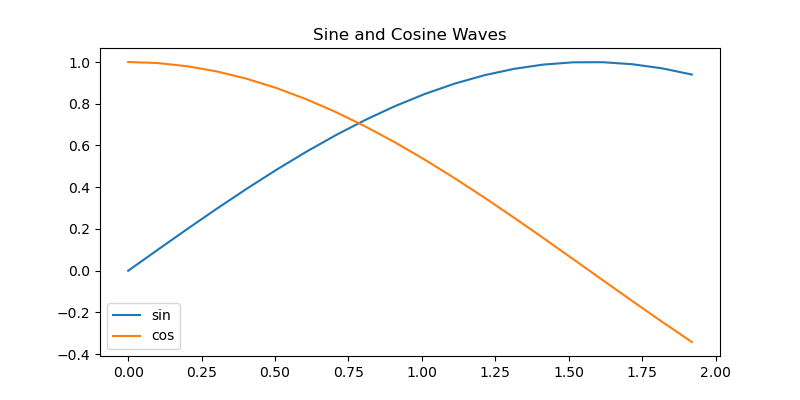

*Figure 1: First few periods of sine and cosine waves*

## <span class="todo TODO">TODO</span> Also use dataframe<sub>image</sub> to get styled dataframes from the html output as pngs.

# Error handling

In [ ]:
print(1 / 0)


╭───────────────────── Traceback (most recent call last)
──────────────────────╮ │ in \<module\>:28 │ │
╭───────────────────────────────── locals
─────────────────────────────────╮ │ │ │ ast = \<module 'ast' from │ │ │
│ '/nix/store/bm0zc89iq0aml2afkqq5j7sy0ax7cwp6-python3-3.1… │ │ │ │ f =
\<<sub>io</sub>.TextIOWrapper name='/tmp/babel-pnB2aZ/python-G3FRkP' │ │
│ │ mode='r' encoding='UTF-8'\> │ │ │ │ os = \<module 'os' (frozen)\> │
│ │ │ re = \<module 're' from │ │ │ │
'/nix/store/bm0zc89iq0aml2afkqq5j7sy0ax7cwp6-python3-3.1… │ │ │ │
readline = \<module 'readline' from │ │ │ │
'/nix/store/bm0zc89iq0aml2afkqq5j7sy0ax7cwp6-python3-3.1… │ │ │ │
rich<sub>console</sub> = \<console width=80 None\> │ │ │ │ subprocess =
\<module 'subprocess' from │ │ │ │
'/nix/store/bm0zc89iq0aml2afkqq5j7sy0ax7cwp6-python3-3.1… │ │ │ │ sys =
\<module 'sys' (built-in)\> │ │ │ │ time = \<module 'time' (built-in)\>
│ │ │ │ tty = \<module 'tty' from │ │ │ │
'/nix/store/bm0zc89iq0aml2afkqq5j7sy0ax7cwp6-python3-3.1… │ │ │
╰──────────────────────────────────────────────────────────────────────────╯
│ │ in \<module\>:1 │ │ ╭───────────────────────────────── locals
─────────────────────────────────╮ │ │ │ ast = \<module 'ast' from │ │ │
│ '/nix/store/bm0zc89iq0aml2afkqq5j7sy0ax7cwp6-python3-3.1… │ │ │ │ f =
\<<sub>io</sub>.TextIOWrapper name='/tmp/babel-pnB2aZ/python-G3FRkP' │ │
│ │ mode='r' encoding='UTF-8'\> │ │ │ │ os = \<module 'os' (frozen)\> │
│ │ │ re = \<module 're' from │ │ │ │
'/nix/store/bm0zc89iq0aml2afkqq5j7sy0ax7cwp6-python3-3.1… │ │ │ │
readline = \<module 'readline' from │ │ │ │
'/nix/store/bm0zc89iq0aml2afkqq5j7sy0ax7cwp6-python3-3.1… │ │ │ │
rich<sub>console</sub> = \<console width=80 None\> │ │ │ │ subprocess =
\<module 'subprocess' from │ │ │ │
'/nix/store/bm0zc89iq0aml2afkqq5j7sy0ax7cwp6-python3-3.1… │ │ │ │ sys =
\<module 'sys' (built-in)\> │ │ │ │ time = \<module 'time' (built-in)\>
│ │ │ │ tty = \<module 'tty' from │ │ │ │
'/nix/store/bm0zc89iq0aml2afkqq5j7sy0ax7cwp6-python3-3.1… │ │ │
╰──────────────────────────────────────────────────────────────────────────╯
│
╰──────────────────────────────────────────────────────────────────────────────╯
ZeroDivisionError: division by zero

In [ ]:
x = 0
print(1 / 0)


╭───────────────────── Traceback (most recent call last)
──────────────────────╮ │ in \<module\>:28 │ │ in \<module\>:1 │
╰──────────────────────────────────────────────────────────────────────────────╯
ZeroDivisionError: division by zero

## <span class="todo TODO">TODO</span> Get more detailed errors

# Last line print

In [ ]:
x = 1
print(x)
1000 * 2 + x


1 2001

## Edge case handling

Last line might not be an expression. Ideally this would get the last
expression, but I'm settling for just not crashing.

(Achieved by checking if the code without the last line is valid python
before execing it first; otherwise exec's the whole block. I don't like
relying on \_.)

In [ ]:
(
    1,
    2,
    3,
    4,
    1,
)


Need to make sure that we handle comments on the last line – in general,
print(last<sub>line</sub>) is checked to be valid python syntax.

In [ ]:
print(1)
# a comment


1